# 🔍 피처 군집 분석 (Feature Clustering with CRNN)

이 노트북에서는 **combined 폴더를 제외**하고 CRNN 모델을 사용하여 차량 사운드 피처의 군집 분석을 수행합니다.

## 📋 목차
1. **데이터 로드**: combined 폴더 제외
2. **피처 추출**: CRNN용 피처 추출
3. **군집 분석**: PCA 시각화 + K-means 클러스터링
4. **CRNN 모델 학습**: 상태(State) 분류 모델
5. **피처 비교**: 다양한 피처 추출 방식 비교


In [ ]:
# ============================================================
# 필수 라이브러리 임포트
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from collections import Counter

# 공통 유틸리티
from utils import setup_plotting, get_data_dir, get_state_mapping, get_state_names

# 머신러닝
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    adjusted_rand_score, normalized_mutual_info_score,
    silhouette_score
)
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import librosa

# 프로젝트 모듈
from app.ml.models.crnn import SoundClassifierCRNN
from app.ml.features.extractor import AudioFeatureExtractor, AudioConfig
from app.ml.features.augmentation import AudioAugmentor, AugmentationConfig
from app.ml.training.trainer import Trainer, create_optimizer, create_scheduler

# 시각화 설정
setup_plotting()

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 라이브러리 로드 완료!")
print(f"🖥️ Device: {device}")


✅ 라이브러리 로드 완료!
🖥️ Device: cpu


---
## 1. 데이터 로드 (combined 폴더 제외)


In [ ]:
# ============================================================
# 데이터 경로 수집 (combined 폴더 제외)
# ============================================================

data_dir = get_data_dir()
augmented_dir = data_dir / 'augmented'

# 파일 경로와 레이블 수집
all_files = []
all_states = []      # 1단계: 상태 (braking, idle, startup)
all_problems = []    # 2단계: 세부 문제

# 상태 매핑
state_mapping = get_state_mapping()
state_names = get_state_names()

print("📂 데이터 로드 중... (combined 폴더 제외)")

# 원본 데이터 수집
for state_dir in sorted(data_dir.iterdir()):
    if not state_dir.is_dir() or state_dir.name == 'augmented':
        continue
    
    state_name = state_dir.name
    state_idx = state_mapping.get(state_name, -1)
    
    if state_idx == -1:
        continue
    
    for problem_dir in sorted(state_dir.iterdir()):
        if not problem_dir.is_dir():
            continue
        
        problem_name = problem_dir.name
        
        # ⚠️ combined 폴더 제외
        if problem_name == 'combined':
            print(f"   ⏭️  제외: {state_name}/{problem_name}")
            continue
        
        # WAV 파일 수집
        wav_files = list(problem_dir.glob('*.wav'))
        for f in wav_files:
            all_files.append(f)
            all_states.append(state_idx)
            all_problems.append(f"{state_name}/{problem_name}")
        
        # 하위 폴더 확인 (combined 제외)
        for sub_dir in problem_dir.iterdir():
            if sub_dir.is_dir() and sub_dir.name != 'combined':
                sub_files = list(sub_dir.glob('*.wav'))
                for f in sub_files:
                    all_files.append(f)
                    all_states.append(state_idx)
                    all_problems.append(f"{state_name}/{problem_name}/{sub_dir.name}")

original_count = len(all_files)
print(f"   원본 샘플: {original_count}개")

# 증강 데이터 수집
if augmented_dir.exists():
    for state_dir in sorted(augmented_dir.iterdir()):
        if not state_dir.is_dir():
            continue
        
        state_name = state_dir.name
        state_idx = state_mapping.get(state_name, -1)
        
        if state_idx == -1:
            continue
        
        for problem_dir in sorted(state_dir.iterdir()):
            if not problem_dir.is_dir():
                continue
            
            problem_name = problem_dir.name
            
            # ⚠️ combined 폴더 제외
            if problem_name == 'combined':
                continue
            
            # 증강 WAV 파일 수집
            aug_files = list(problem_dir.glob('*.wav'))
            for f in aug_files:
                all_files.append(f)
                all_states.append(state_idx)
                all_problems.append(f"{state_name}/{problem_name}")
            
            # 하위 폴더 확인 (combined 제외)
            for sub_dir in problem_dir.iterdir():
                if sub_dir.is_dir() and sub_dir.name != 'combined':
                    sub_files = list(sub_dir.glob('*.wav'))
                    for f in sub_files:
                        all_files.append(f)
                        all_states.append(state_idx)
                        all_problems.append(f"{state_name}/{problem_name}/{sub_dir.name}")

augmented_count = len(all_files) - original_count
print(f"   증강 샘플: {augmented_count}개")

print("\n" + "=" * 50)
print(f"📊 총 데이터: {len(all_files)}개 (combined 제외)")
print("=" * 50)

# 상태별 분포 확인
state_counts = Counter(all_states)
print("\n📊 상태별 분포:")
for idx, name in enumerate(state_names):
    print(f"  [{idx}] {name}: {state_counts[idx]}개")


📂 데이터 로드 중... (combined 폴더 제외)
   ⏭️  제외: idle state/combined
   원본 샘플: 949개
   증강 샘플: 1883개

📊 총 데이터: 2832개 (combined 제외)

📊 상태별 분포:
  [0] braking: 612개
  [1] idle: 1320개
  [2] startup: 900개


---
## 2. 피처 추출기 초기화


In [5]:
# ============================================================
# 피처 추출기 초기화
# ============================================================

audio_config = AudioConfig(
    sample_rate=22050,
    duration=5.0,
    n_mels=128,
    n_mfcc=40,
    n_fft=2048,
    hop_length=512
)

feature_extractor = AudioFeatureExtractor(config=audio_config)
print("✅ 피처 추출기 초기화 완료!")


✅ 피처 추출기 초기화 완료!


---
## 3. 피처 추출 (군집 분석용)


In [6]:
# ============================================================
# 피처 추출 (군집 분석용)
# ============================================================

print("🔄 피처 추출 중... (시간이 걸릴 수 있습니다)")

# 모든 샘플에서 피처 추출
all_features = []

for file_path in tqdm(all_files, desc="피처 추출"):
    try:
        # CRNN용 피처 추출 (Mel Spectrogram)
        features = feature_extractor.extract_for_cnn(str(file_path))
        # Flatten하여 1D 벡터로 변환
        features_flat = features.flatten()
        all_features.append(features_flat)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        # 오류 시 0으로 채움
        all_features.append(np.zeros(128 * 216))

# NumPy 배열로 변환
X = np.array(all_features)
y_state = np.array(all_states)

print(f"\n✅ 피처 추출 완료!")
print(f"   X shape: {X.shape}")
print(f"   y_state shape: {y_state.shape}")


🔄 피처 추출 중... (시간이 걸릴 수 있습니다)


피처 추출: 100%|██████████| 2832/2832 [00:32<00:00, 86.30it/s] 


✅ 피처 추출 완료!
   X shape: (2832, 27648)
   y_state shape: (2832,)


---
## 4. 다양한 피처 추출 방식 비교


### 🔬 다양한 피처 추출 방식 비교

여러 가지 피처 추출 방식으로 PCA를 수행하여 어떤 피처가 클래스를 가장 잘 분리하는지 비교합니다.

| 피처 | 차원 | 특성 |
|-----|-----|------|
| Mel Spectrogram | 128 × T | 주파수-시간 전체 패턴 |
| MFCC | 40 × T | 스펙트럼의 음색 특성 |
| MFCC + Delta | 120 × T | 음색 + 시간적 변화 |
| Chroma | 12 × T | 12개 음계 기반 |
| Spectral Contrast | 7 × T | 주파수 대역별 대비 |
| Spectral Features | 5 × T | 통계적 특성 |
| Combined (통계) | 모두 결합 | 종합 피처 |


In [7]:
# ============================================================
# 다양한 피처 추출 함수 정의
# ============================================================

def extract_multiple_features(file_path, feature_extractor, sr=22050):
    """
    다양한 피처를 추출하는 함수
    
    Returns:
        dict: 각 피처 종류별 추출된 값
    """
    # 오디오 로드
    y, sr = feature_extractor.load_audio(str(file_path))
    
    features = {}
    
    # 1. Mel Spectrogram (기본)
    mel_spec = feature_extractor.extract_mel_spectrogram(y, sr)
    features['mel_spectrogram'] = mel_spec.flatten()
    
    # 2. MFCC (Delta 없이)
    mfcc = feature_extractor.extract_mfcc(y, sr, include_delta=False)
    features['mfcc'] = mfcc.flatten()
    
    # 3. MFCC + Delta + Delta2
    mfcc_delta = feature_extractor.extract_mfcc(y, sr, include_delta=True)
    features['mfcc_delta'] = mfcc_delta.flatten()
    
    # 4. Chroma
    chroma = feature_extractor.extract_chroma(y, sr)
    features['chroma'] = chroma.flatten()
    
    # 5. Spectral Contrast
    contrast = feature_extractor.extract_spectral_contrast(y, sr)
    features['spectral_contrast'] = contrast.flatten()
    
    # 6. Spectral Features (통계적 특성)
    spectral = feature_extractor.extract_spectral_features(y, sr)
    spectral_combined = np.concatenate([
        spectral['spectral_centroid'].flatten(),
        spectral['spectral_bandwidth'].flatten(),
        spectral['spectral_rolloff'].flatten(),
        spectral['zero_crossing_rate'].flatten(),
        spectral['rms'].flatten()
    ])
    features['spectral_features'] = spectral_combined
    
    # 7. 통계 기반 피처 (평균, 표준편차)
    mel_stats = np.concatenate([
        mel_spec.mean(axis=1),  # 각 Mel 밴드의 평균
        mel_spec.std(axis=1),   # 각 Mel 밴드의 표준편차
        mel_spec.max(axis=1),   # 각 Mel 밴드의 최대값
        mel_spec.min(axis=1)    # 각 Mel 밴드의 최소값
    ])
    features['mel_stats'] = mel_stats
    
    mfcc_stats = np.concatenate([
        mfcc.mean(axis=1),
        mfcc.std(axis=1),
        mfcc.max(axis=1),
        mfcc.min(axis=1)
    ])
    features['mfcc_stats'] = mfcc_stats
    
    # 8. Combined (모든 통계 피처 결합)
    features['combined_stats'] = np.concatenate([
        mel_stats,
        mfcc_stats,
        chroma.mean(axis=1),
        chroma.std(axis=1),
        contrast.mean(axis=1),
        contrast.std(axis=1),
        spectral_combined.mean(keepdims=True) if spectral_combined.ndim > 0 else spectral_combined
    ])
    
    return features

print("✅ 다양한 피처 추출 함수 정의 완료!")


✅ 다양한 피처 추출 함수 정의 완료!


In [8]:
# ============================================================
# 모든 피처 추출 (다양한 방식)
# ============================================================

print("🔄 다양한 피처 추출 중... (시간이 걸릴 수 있습니다)")

# 피처 저장용 딕셔너리
feature_dict = {
    'mel_spectrogram': [],
    'mfcc': [],
    'mfcc_delta': [],
    'chroma': [],
    'spectral_contrast': [],
    'spectral_features': [],
    'mel_stats': [],
    'mfcc_stats': [],
    'combined_stats': []
}

# 샘플링 (전체 데이터가 너무 많으면 일부만 사용)
MAX_SAMPLES = min(1000, len(all_files))  # 최대 1000개 샘플
sample_indices = np.random.choice(len(all_files), MAX_SAMPLES, replace=False)
sampled_files = [all_files[i] for i in sample_indices]
sampled_states = [all_states[i] for i in sample_indices]

print(f"   샘플링: {len(all_files)}개 중 {MAX_SAMPLES}개 사용")

for file_path in tqdm(sampled_files, desc="다양한 피처 추출"):
    try:
        features = extract_multiple_features(file_path, feature_extractor)
        for key in feature_dict.keys():
            feature_dict[key].append(features[key])
    except Exception as e:
        print(f"Error: {file_path.name} - {e}")
        # 오류 시 0으로 채움
        for key in feature_dict.keys():
            if len(feature_dict[key]) > 0:
                feature_dict[key].append(np.zeros_like(feature_dict[key][-1]))

# NumPy 배열로 변환
for key in feature_dict.keys():
    feature_dict[key] = np.array(feature_dict[key])

y_sampled = np.array(sampled_states)

print(f"\n✅ 다양한 피처 추출 완료!")
print("\n📊 피처별 차원:")
for key, value in feature_dict.items():
    print(f"   {key}: {value.shape}")


🔄 다양한 피처 추출 중... (시간이 걸릴 수 있습니다)
   샘플링: 2832개 중 1000개 사용


다양한 피처 추출: 100%|██████████| 1000/1000 [01:28<00:00, 11.25it/s]



✅ 다양한 피처 추출 완료!

📊 피처별 차원:
   mel_spectrogram: (1000, 27648)
   mfcc: (1000, 8640)
   mfcc_delta: (1000, 25920)
   chroma: (1000, 2592)
   spectral_contrast: (1000, 1512)
   spectral_features: (1000, 1080)
   mel_stats: (1000, 512)
   mfcc_stats: (1000, 160)
   combined_stats: (1000, 711)


---
## 5. PCA 시각화 및 군집 분석


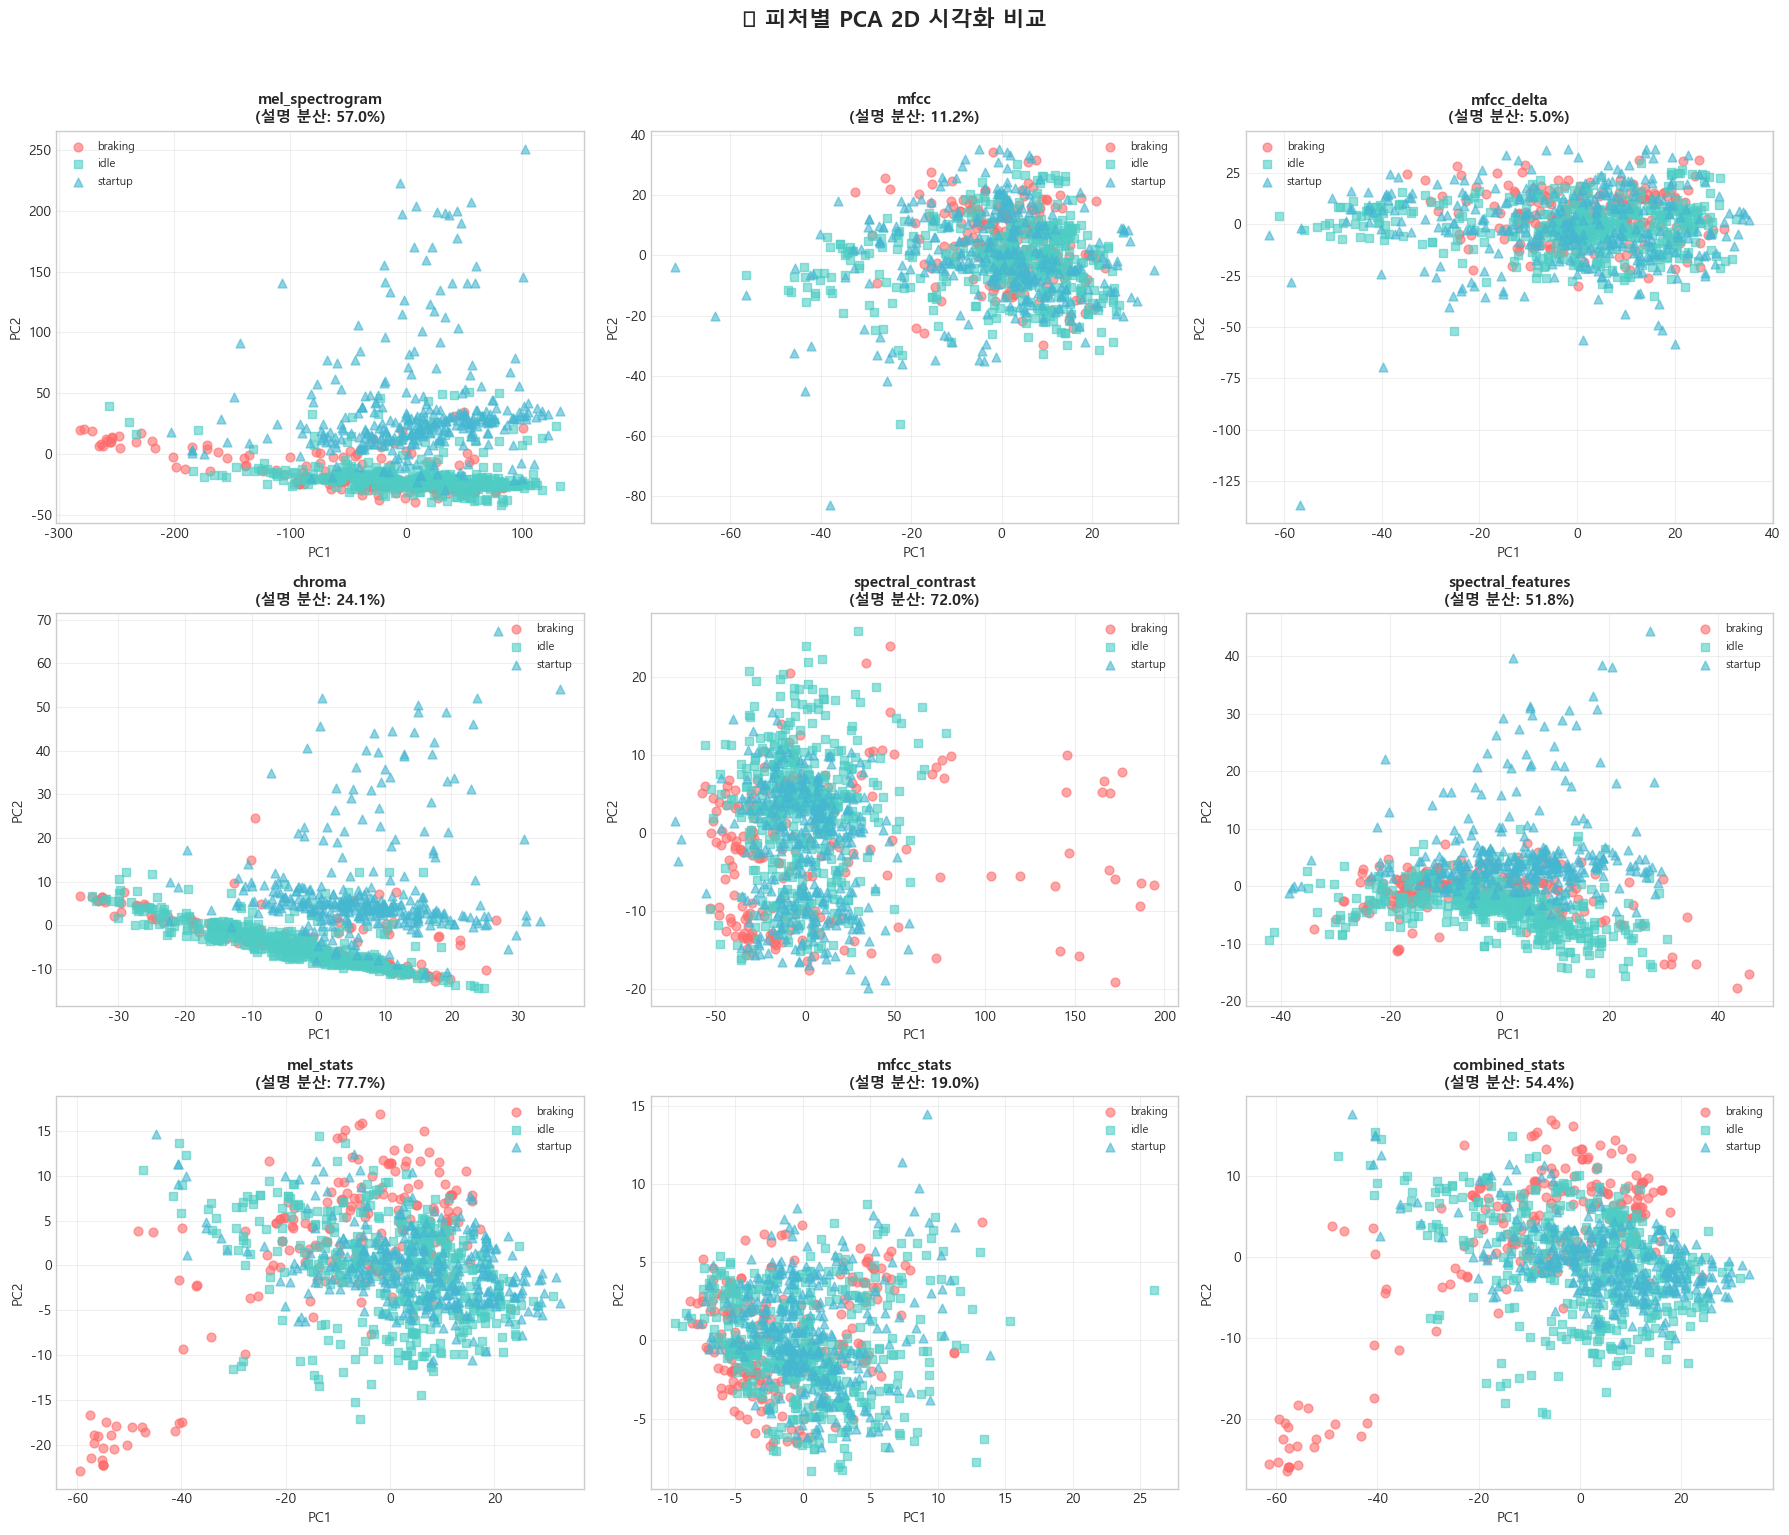

In [9]:
# ============================================================
# 모든 피처에 대해 PCA 수행 및 시각화
# ============================================================

def visualize_pca_comparison(feature_dict, y_labels, state_names):
    """모든 피처에 대해 PCA 2D 시각화 비교"""
    
    n_features = len(feature_dict)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    markers = ['o', 's', '^']
    
    pca_results = {}
    
    for idx, (feature_name, X_feat) in enumerate(feature_dict.items()):
        ax = axes[idx]
        
        # 정규화
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_feat)
        
        # PCA
        pca = PCA(n_components=2, random_state=42)
        X_pca = pca.fit_transform(X_scaled)
        
        # 저장
        pca_results[feature_name] = {
            'X_pca': X_pca,
            'explained_variance': pca.explained_variance_ratio_.sum(),
            'X_scaled': X_scaled
        }
        
        # 시각화
        for state_idx, (name, color, marker) in enumerate(zip(state_names, colors, markers)):
            mask = y_labels == state_idx
            ax.scatter(
                X_pca[mask, 0], X_pca[mask, 1],
                c=color, marker=marker,
                label=name, alpha=0.6, s=40
            )
        
        explained = pca.explained_variance_ratio_.sum() * 100
        ax.set_title(f'{feature_name}\n(설명 분산: {explained:.1f}%)', fontsize=11, fontweight='bold')
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # 빈 축 숨기기
    for idx in range(len(feature_dict), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('🔬 피처별 PCA 2D 시각화 비교', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return pca_results

# PCA 시각화 수행
pca_results = visualize_pca_comparison(feature_dict, y_sampled, state_names)


In [10]:
# ============================================================
# 피처별 클러스터링 성능 비교
# ============================================================

def compare_clustering_performance(feature_dict, y_labels, state_names):
    """각 피처에 대해 K-means 클러스터링 성능 비교"""
    
    results = []
    
    for feature_name, X_feat in feature_dict.items():
        # 정규화
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_feat)
        
        # K-means 클러스터링
        kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
        cluster_labels = kmeans.fit_predict(X_scaled)
        
        # 성능 평가
        silhouette = silhouette_score(X_scaled, cluster_labels)
        ari = adjusted_rand_score(y_labels, cluster_labels)
        nmi = normalized_mutual_info_score(y_labels, cluster_labels)
        
        results.append({
            'Feature': feature_name,
            'Silhouette': silhouette,
            'ARI': ari,
            'NMI': nmi,
            'Dimension': X_feat.shape[1]
        })
    
    return pd.DataFrame(results)

# 클러스터링 성능 비교
df_results = compare_clustering_performance(feature_dict, y_sampled, state_names)

# 결과 정렬 (ARI 기준)
df_results_sorted = df_results.sort_values('ARI', ascending=False)

print("=" * 70)
print("📊 피처별 클러스터링 성능 비교 (K-means, k=3)")
print("=" * 70)
print(df_results_sorted.to_string(index=False))
print("\n💡 ARI (Adjusted Rand Index)가 높을수록 실제 레이블과 일치도가 높습니다.")


📊 피처별 클러스터링 성능 비교 (K-means, k=3)
          Feature  Silhouette      ARI      NMI  Dimension
           chroma    0.110589 0.044890 0.099974       2592
        mel_stats    0.303296 0.041612 0.038893        512
   combined_stats    0.194763 0.040090 0.037471        711
  mel_spectrogram    0.199616 0.039416 0.030349      27648
spectral_features    0.179007 0.032847 0.039837       1080
spectral_contrast    0.266678 0.023872 0.049683       1512
       mfcc_delta    0.005712 0.006308 0.012701      25920
       mfcc_stats    0.066539 0.003918 0.011269        160
             mfcc    0.033844 0.003677 0.018066       8640

💡 ARI (Adjusted Rand Index)가 높을수록 실제 레이블과 일치도가 높습니다.


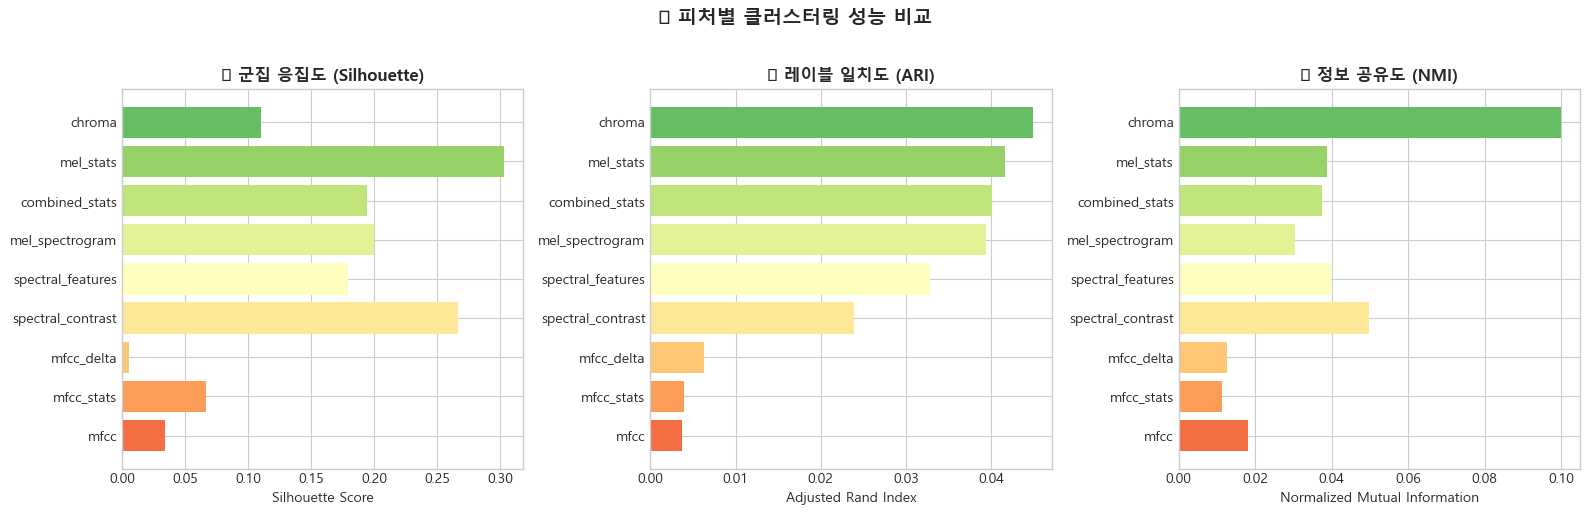


🏆 최고 성능 피처: chroma (ARI: 0.0449)


In [11]:
# ============================================================
# 성능 비교 시각화
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 결과를 피처 이름 순서대로 정렬
df_plot = df_results.sort_values('ARI', ascending=True)

# 1. Silhouette Score
colors = plt.cm.get_cmap('RdYlGn')(np.linspace(0.2, 0.8, len(df_plot)))
axes[0].barh(df_plot['Feature'], df_plot['Silhouette'], color=colors)
axes[0].set_xlabel('Silhouette Score')
axes[0].set_title('🔵 군집 응집도 (Silhouette)', fontweight='bold')
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# 2. Adjusted Rand Index
colors = plt.cm.get_cmap('RdYlGn')(np.linspace(0.2, 0.8, len(df_plot)))
axes[1].barh(df_plot['Feature'], df_plot['ARI'], color=colors)
axes[1].set_xlabel('Adjusted Rand Index')
axes[1].set_title('🎯 레이블 일치도 (ARI)', fontweight='bold')

# 3. NMI
colors = plt.cm.get_cmap('RdYlGn')(np.linspace(0.2, 0.8, len(df_plot)))
axes[2].barh(df_plot['Feature'], df_plot['NMI'], color=colors)
axes[2].set_xlabel('Normalized Mutual Information')
axes[2].set_title('📊 정보 공유도 (NMI)', fontweight='bold')

plt.suptitle('📈 피처별 클러스터링 성능 비교', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 최고 성능 피처 출력
best_feature = df_results.loc[df_results['ARI'].idxmax(), 'Feature']
best_ari = df_results['ARI'].max()
print(f"\n🏆 최고 성능 피처: {best_feature} (ARI: {best_ari:.4f})")


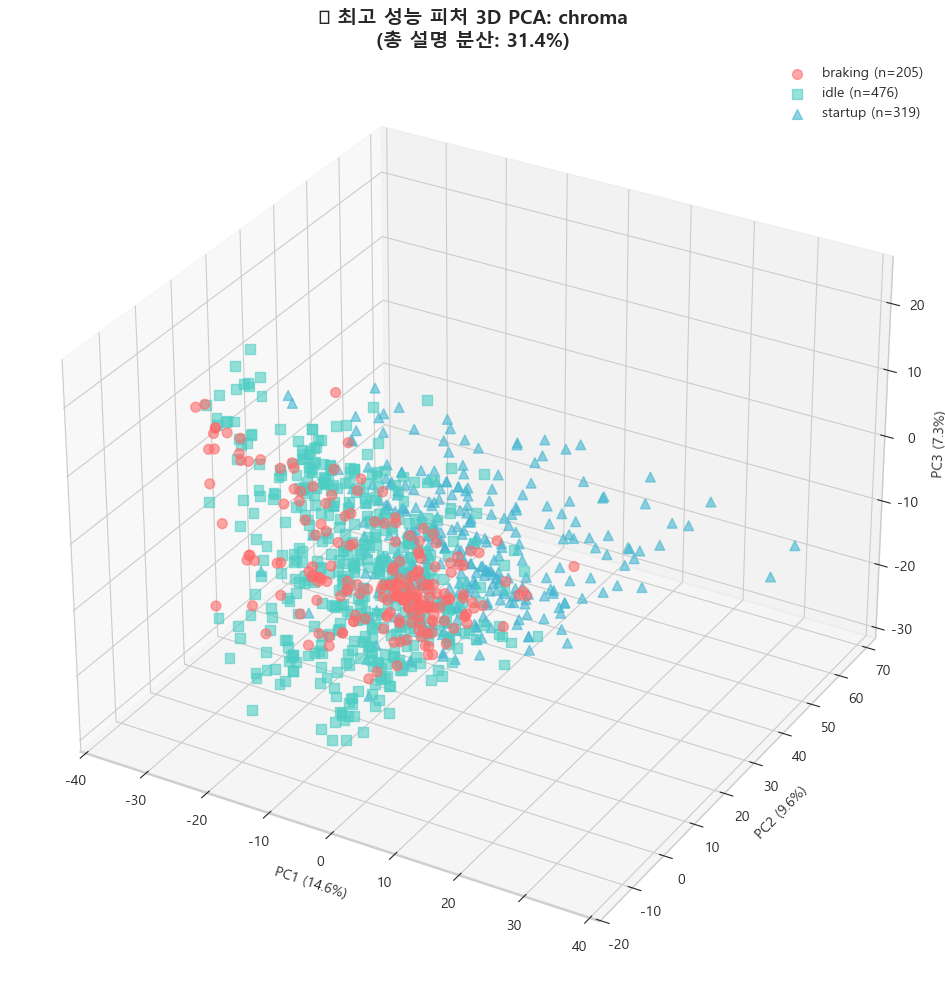

In [12]:
# ============================================================
# 최고 성능 피처로 3D PCA 시각화
# ============================================================

from mpl_toolkits.mplot3d import Axes3D

# 최고 성능 피처 선택
best_feature = df_results.loc[df_results['ARI'].idxmax(), 'Feature']
X_best = feature_dict[best_feature]

# 정규화 및 3D PCA
scaler = StandardScaler()
X_best_scaled = scaler.fit_transform(X_best)

pca_3d = PCA(n_components=3, random_state=42)
X_best_3d = pca_3d.fit_transform(X_best_scaled)

# 3D 시각화
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
markers = ['o', 's', '^']

for state_idx, (name, color, marker) in enumerate(zip(state_names, colors, markers)):
    mask = y_sampled == state_idx
    ax.scatter(
        X_best_3d[mask, 0],
        X_best_3d[mask, 1],
        X_best_3d[mask, 2],
        c=color, marker=marker,
        label=f'{name} (n={mask.sum()})',
        alpha=0.6, s=50
    )

explained = pca_3d.explained_variance_ratio_.sum() * 100
ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})')
ax.set_title(f'🏆 최고 성능 피처 3D PCA: {best_feature}\n(총 설명 분산: {explained:.1f}%)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best')

plt.tight_layout()
plt.show()


---
## 6. 전체 데이터 PCA 및 K-means 클러스터링


In [13]:
# ============================================================
# 데이터 정규화 및 PCA
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ 데이터 정규화 완료!")

# 2D PCA
print("🔄 PCA 수행 중...")
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"\n✅ PCA (2D) 완료!")
print(f"   설명된 분산 비율: {pca_2d.explained_variance_ratio_.sum():.4f}")
print(f"   PC1: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"   PC2: {pca_2d.explained_variance_ratio_[1]:.4f}")


✅ 데이터 정규화 완료!
🔄 PCA 수행 중...

✅ PCA (2D) 완료!
   설명된 분산 비율: 0.6826
   PC1: 0.6225
   PC2: 0.0601


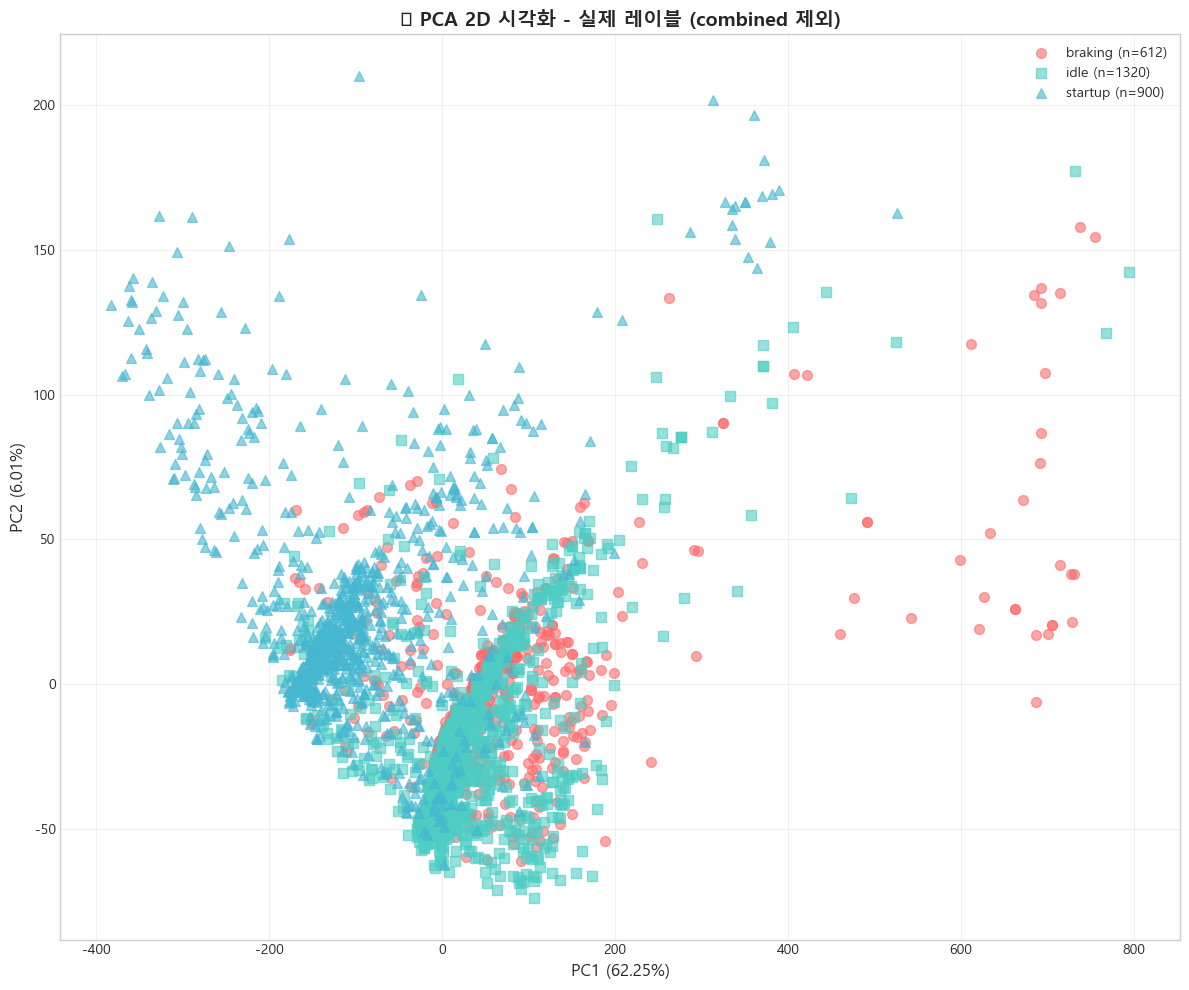


💡 해석:
  • 같은 색상(상태)의 점들이 모여있을수록 분류가 쉬움
  • 겹치는 영역이 많으면 분류가 어려울 수 있음


In [14]:
# ============================================================
# PCA 2D 시각화 (실제 레이블 기준)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 10))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # 빨강, 청록, 파랑
markers = ['o', 's', '^']

for idx, (name, color, marker) in enumerate(zip(state_names, colors, markers)):
    mask = y_state == idx
    ax.scatter(
        X_pca_2d[mask, 0], 
        X_pca_2d[mask, 1], 
        c=color, 
        marker=marker,
        label=f'{name} (n={mask.sum()})',
        alpha=0.6,
        s=50
    )

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})', fontsize=12)
ax.set_title('🎯 PCA 2D 시각화 - 실제 레이블 (combined 제외)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 해석:")
print("  • 같은 색상(상태)의 점들이 모여있을수록 분류가 쉬움")
print("  • 겹치는 영역이 많으면 분류가 어려울 수 있음")


✅ PCA (3D) 완료!
   설명된 분산 비율: 0.7253


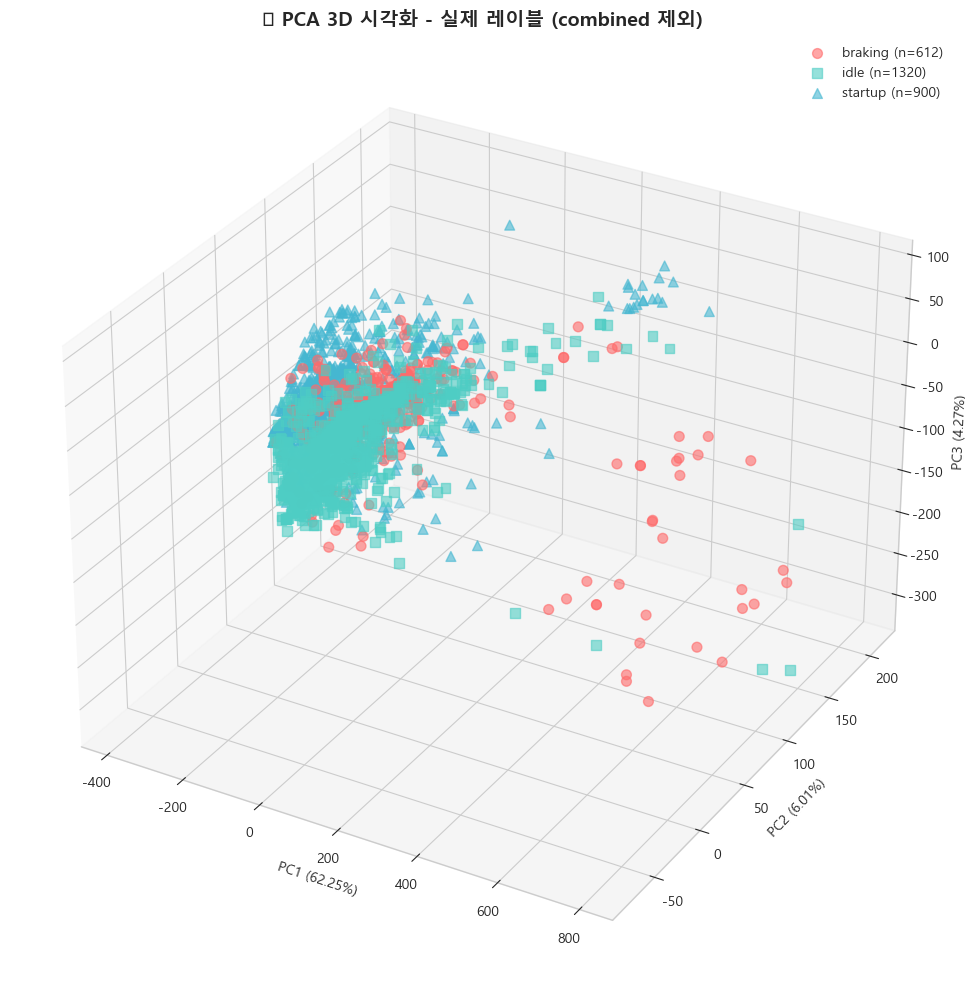

In [15]:
# ============================================================
# PCA 3D 시각화
# ============================================================

from mpl_toolkits.mplot3d import Axes3D

# 3D PCA
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"✅ PCA (3D) 완료!")
print(f"   설명된 분산 비율: {pca_3d.explained_variance_ratio_.sum():.4f}")

# 3D 시각화
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

for idx, (name, color, marker) in enumerate(zip(state_names, colors, markers)):
    mask = y_state == idx
    ax.scatter(
        X_pca_3d[mask, 0], 
        X_pca_3d[mask, 1], 
        X_pca_3d[mask, 2],
        c=color, 
        marker=marker,
        label=f'{name} (n={mask.sum()})',
        alpha=0.6,
        s=50
    )

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})')
ax.set_title('🎯 PCA 3D 시각화 - 실제 레이블 (combined 제외)', fontsize=14, fontweight='bold')
ax.legend(loc='best')

plt.tight_layout()
plt.show()


In [16]:
# ============================================================
# K-Means 클러스터링
# ============================================================

print("🔄 K-Means 클러스터링 수행 중...")

# K=3으로 클러스터링 (3개 상태에 맞춤)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_scaled)

print(f"\n✅ K-Means 클러스터링 완료!")

# 클러스터별 분포
cluster_counts = Counter(cluster_labels)
print("\n📊 클러스터별 샘플 수:")
for cluster_id in sorted(cluster_counts.keys()):
    print(f"  Cluster {cluster_id}: {cluster_counts[cluster_id]}개")


🔄 K-Means 클러스터링 수행 중...

✅ K-Means 클러스터링 완료!

📊 클러스터별 샘플 수:
  Cluster 0: 78개
  Cluster 1: 811개
  Cluster 2: 1943개


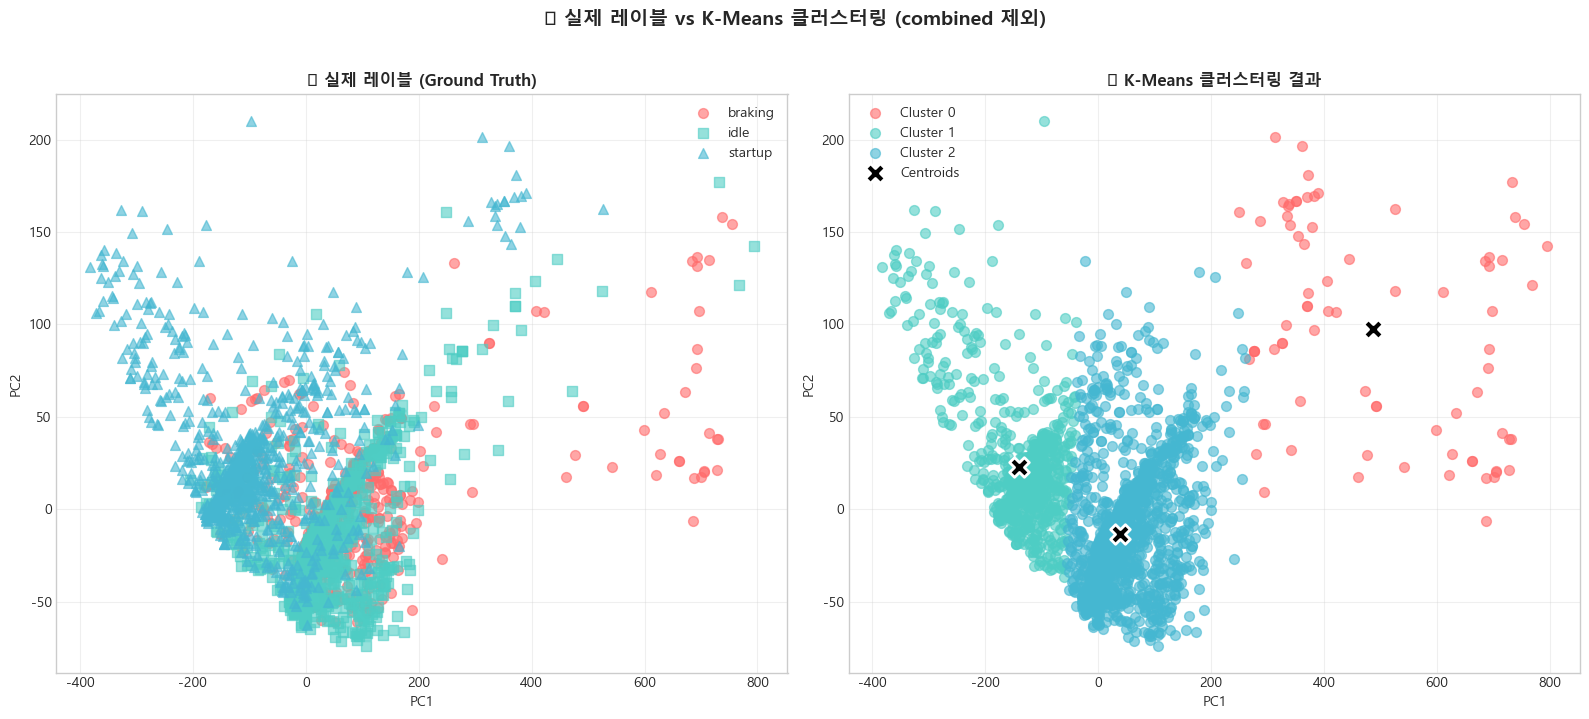

In [17]:
# ============================================================
# 클러스터링 결과 시각화
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 좌측: 실제 레이블
for idx, (name, color, marker) in enumerate(zip(state_names, colors, markers)):
    mask = y_state == idx
    axes[0].scatter(
        X_pca_2d[mask, 0], 
        X_pca_2d[mask, 1], 
        c=color, 
        marker=marker,
        label=f'{name}',
        alpha=0.6,
        s=50
    )
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('✅ 실제 레이블 (Ground Truth)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 우측: K-Means 클러스터
cluster_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for cluster_id in range(3):
    mask = cluster_labels == cluster_id
    axes[1].scatter(
        X_pca_2d[mask, 0], 
        X_pca_2d[mask, 1], 
        c=cluster_colors[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.6,
        s=50
    )

# 클러스터 중심 표시
centers_pca = pca_2d.transform(kmeans.cluster_centers_)
axes[1].scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    c='black', marker='X', s=200, edgecolors='white', linewidths=2,
    label='Centroids'
)

axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('🔵 K-Means 클러스터링 결과', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('📊 실제 레이블 vs K-Means 클러스터링 (combined 제외)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [18]:
# ============================================================
# 클러스터링 성능 평가
# ============================================================

# 1. Silhouette Score (군집 응집도)
silhouette = silhouette_score(X_scaled, cluster_labels)

# 2. Adjusted Rand Index (실제 레이블과의 일치도)
ari = adjusted_rand_score(y_state, cluster_labels)

# 3. Normalized Mutual Information
nmi = normalized_mutual_info_score(y_state, cluster_labels)

print("=" * 60)
print("📊 클러스터링 성능 평가")
print("=" * 60)
print(f"\n1️⃣ Silhouette Score: {silhouette:.4f}")
print("   (-1 ~ 1, 높을수록 군집이 잘 분리됨)")
print(f"\n2️⃣ Adjusted Rand Index (ARI): {ari:.4f}")
print("   (0 ~ 1, 높을수록 실제 레이블과 일치)")
print(f"\n3️⃣ Normalized Mutual Information (NMI): {nmi:.4f}")
print("   (0 ~ 1, 높을수록 실제 레이블과 일치)")


📊 클러스터링 성능 평가

1️⃣ Silhouette Score: 0.3826
   (-1 ~ 1, 높을수록 군집이 잘 분리됨)

2️⃣ Adjusted Rand Index (ARI): 0.3062
   (0 ~ 1, 높을수록 실제 레이블과 일치)

3️⃣ Normalized Mutual Information (NMI): 0.2882
   (0 ~ 1, 높을수록 실제 레이블과 일치)



📊 클러스터-레이블 교차표:
State    braking  idle  startup
Cluster                        
0             39    21       18
1             45    90      676
2            528  1209      206


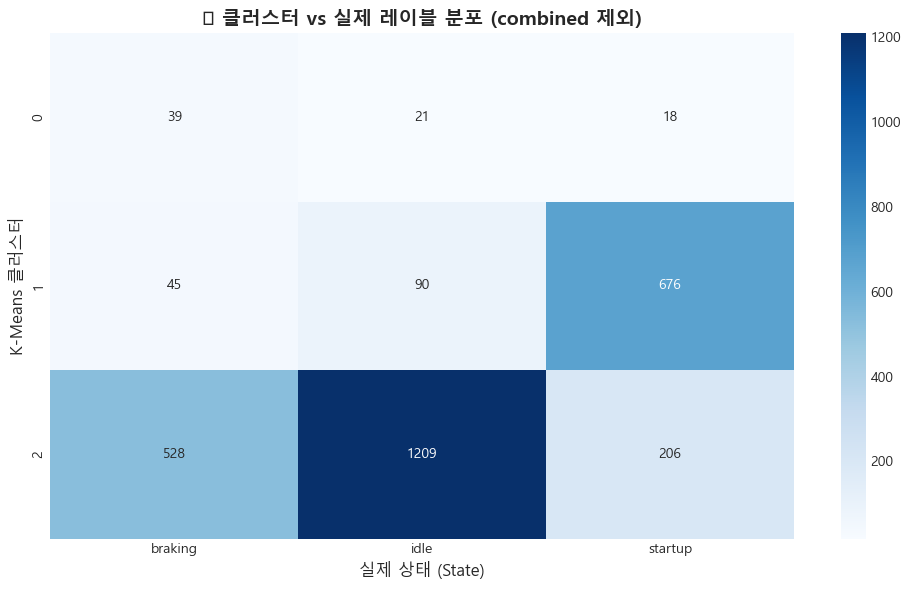


💡 클러스터별 주요 구성:

  Cluster 0:
    braking: 39개 (50.0%)
    idle: 21개 (26.9%)
    startup: 18개 (23.1%)

  Cluster 1:
    startup: 676개 (83.4%)
    idle: 90개 (11.1%)
    braking: 45개 (5.5%)

  Cluster 2:
    idle: 1209개 (62.2%)
    braking: 528개 (27.2%)
    startup: 206개 (10.6%)


In [19]:
# ============================================================
# 클러스터-레이블 매칭 분석
# ============================================================

# 혼동 행렬: 클러스터 vs 실제 레이블
contingency = pd.crosstab(
    pd.Series(cluster_labels, name='Cluster'),
    pd.Series(y_state, name='State').map(lambda x: state_names[x])
)

print("\n📊 클러스터-레이블 교차표:")
print(contingency)

# 히트맵 시각화
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    contingency, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    ax=ax
)
ax.set_title('🔍 클러스터 vs 실제 레이블 분포 (combined 제외)', fontsize=14, fontweight='bold')
ax.set_xlabel('실제 상태 (State)', fontsize=12)
ax.set_ylabel('K-Means 클러스터', fontsize=12)
plt.tight_layout()
plt.show()

# 각 클러스터의 주요 레이블 분석
print("\n💡 클러스터별 주요 구성:")
for cluster_id in range(3):
    cluster_mask = cluster_labels == cluster_id
    states_in_cluster = y_state[cluster_mask]
    state_dist = Counter(states_in_cluster)
    
    total = sum(state_dist.values())
    print(f"\n  Cluster {cluster_id}:")
    for state_idx, count in sorted(state_dist.items(), key=lambda x: -x[1]):
        pct = count / total * 100
        print(f"    {state_names[state_idx]}: {count}개 ({pct:.1f}%)")


---
## 7. CRNN 모델 학습 (상태 분류)


In [20]:
# ============================================================
# 데이터셋 클래스 정의 (다양한 피처 지원)
# ============================================================

from typing import Optional

class SoundDataset(Dataset):
    """차량 사운드 데이터셋 - 다양한 피처 지원"""
    
    def __init__(
        self,
        file_paths: list,
        labels: list,
        feature_extractor: AudioFeatureExtractor,
        augmentor: Optional[AudioAugmentor] = None,
        apply_spec_augment: bool = False,
        is_training: bool = True,
        use_multi_channel: bool = True  # True: Mel+MFCC, False: Mel만
    ):
        self.file_paths = file_paths
        self.labels = labels
        self.feature_extractor = feature_extractor
        self.augmentor = augmentor
        self.apply_spec_augment = apply_spec_augment
        self.is_training = is_training
        self.use_multi_channel = use_multi_channel
        
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.labels[idx]
        
        # 다양한 피처 사용: Mel + MFCC 결합
        if self.use_multi_channel:
            features = self.feature_extractor.extract_for_crnn(str(file_path))
        else:
            features = self.feature_extractor.extract_for_cnn(str(file_path))
        
        if self.is_training and self.apply_spec_augment and self.augmentor is not None:
            # 멀티채널인 경우 각 채널에 증강 적용
            if features.ndim == 3:  # (channels, freq, time)
                for c in range(features.shape[0]):
                    features[c] = self.augmentor.spec_augment(
                        features[c], num_freq_masks=2, num_time_masks=2,
                        freq_mask_param=15, time_mask_param=35
                    )
            else:  # 단일 채널
                features_2d = features[0]
                features_2d = self.augmentor.spec_augment(
                    features_2d, num_freq_masks=2, num_time_masks=2,
                    freq_mask_param=15, time_mask_param=35
                )
                features = features_2d[np.newaxis, ...]
        
        features_tensor = torch.FloatTensor(features)
        label_tensor = torch.LongTensor([label])[0]
        
        return features_tensor, label_tensor

print("✅ SoundDataset 클래스 정의 완료! (멀티채널 피처 지원)")


✅ SoundDataset 클래스 정의 완료! (멀티채널 피처 지원)


In [21]:
# ============================================================
# CRNN 모델 학습 데이터 준비
# ============================================================

# 데이터 분할
X_train_s, X_temp_s, y_train_s, y_temp_s = train_test_split(
    all_files, all_states,
    test_size=0.3,
    stratify=all_states,
    random_state=42
)

X_val_s, X_test_s, y_val_s, y_test_s = train_test_split(
    X_temp_s, y_temp_s,
    test_size=0.5,
    stratify=y_temp_s,
    random_state=42
)

print("📊 CRNN 모델 (State 분류) 데이터 분할:")
print(f"  • 학습 셋: {len(X_train_s)}개")
print(f"  • 검증 셋: {len(X_val_s)}개")
print(f"  • 테스트 셋: {len(X_test_s)}개")
print(f"  • 클래스 수: 3개 (braking, idle, startup)")


📊 CRNN 모델 (State 분류) 데이터 분할:
  • 학습 셋: 1982개
  • 검증 셋: 425개
  • 테스트 셋: 425개
  • 클래스 수: 3개 (braking, idle, startup)


In [22]:
# ============================================================
# CRNN 모델 학습 (멀티채널 피처: Mel + MFCC)
# ============================================================

# 증강기
aug_config = AugmentationConfig()
augmentor = AudioAugmentor(config=aug_config)

# 데이터셋 생성 (멀티채널: Mel + MFCC 사용)
BATCH_SIZE = 16

train_dataset_s = SoundDataset(
    file_paths=X_train_s, labels=y_train_s,
    feature_extractor=feature_extractor,
    augmentor=augmentor, apply_spec_augment=True, is_training=True,
    use_multi_channel=True  # Mel + MFCC 결합 사용
)

val_dataset_s = SoundDataset(
    file_paths=X_val_s, labels=y_val_s,
    feature_extractor=feature_extractor,
    augmentor=None, apply_spec_augment=False, is_training=False,
    use_multi_channel=True
)

test_dataset_s = SoundDataset(
    file_paths=X_test_s, labels=y_test_s,
    feature_extractor=feature_extractor,
    augmentor=None, apply_spec_augment=False, is_training=False,
    use_multi_channel=True
)

train_loader_s = DataLoader(train_dataset_s, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_s = DataLoader(val_dataset_s, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_s = DataLoader(test_dataset_s, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"✅ DataLoader 생성 완료!")
print(f"   학습 배치: {len(train_loader_s)}, 검증 배치: {len(val_loader_s)}")


✅ DataLoader 생성 완료!
   학습 배치: 124, 검증 배치: 27


In [23]:
# ============================================================
# CRNN 모델 정의 및 학습 (멀티채널: Mel + MFCC)
# ============================================================

NUM_STATES = 3  # braking, idle, startup

# 모델 생성 (멀티채널: Mel + MFCC = 2채널)
state_model = SoundClassifierCRNN(
    num_classes=NUM_STATES,
    in_channels=2,  # Mel + MFCC = 2채널
    cnn_channels=[32, 64, 128],
    rnn_hidden_size=128,
    rnn_num_layers=2,
    dropout=0.3,
    bidirectional=True
)
state_model = state_model.to(device)

print("🏗️ CRNN 모델 (State 분류) - 멀티채널 피처 사용:")
print(f"   클래스: {state_names}")
print(f"   입력 채널: 2 (Mel Spectrogram + MFCC)")
total_params = sum(p.numel() for p in state_model.parameters())
print(f"   파라미터: {total_params:,}")

# 클래스 가중치
state_counts_list = [state_counts[i] for i in range(NUM_STATES)]
class_weights = 1.0 / torch.FloatTensor(state_counts_list)
class_weights = class_weights / class_weights.sum() * NUM_STATES

# 학습 설정
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = create_optimizer(state_model, 'adamw', lr=1e-3, weight_decay=0.01)
scheduler = create_scheduler(optimizer, 'cosine', epochs=20)

# 체크포인트 디렉토리
checkpoint_dir = Path('../checkpoints')
checkpoint_dir.mkdir(exist_ok=True)

# Trainer
state_trainer = Trainer(
    model=state_model,
    train_loader=train_loader_s,
    val_loader=val_loader_s,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=str(device),
    save_dir=str(checkpoint_dir),
    experiment_name='state_classifier_crnn_multichannel_no_combined',
    use_amp=(device.type == 'cuda')
)

# 학습
print("\n🚀 CRNN 모델 학습 시작!")
print("=" * 60)

state_history = state_trainer.train(
    epochs=20,
    early_stopping_patience=7,
    save_best=True,
    verbose=True
)

print("\n✅ CRNN 모델 학습 완료!")


🏗️ CRNN 모델 (State 분류) - 멀티채널 피처 사용:
   클래스: ['braking', 'idle', 'startup']
   입력 채널: 2 (Mel Spectrogram + MFCC)
   파라미터: 2,785,508

🚀 CRNN 모델 학습 시작!

Starting training: state_classifier_crnn_multichannel_no_combined
Device: cpu
Total epochs: 20



Training: 100%|██████████| 124/124 [03:50<00:00,  1.86s/it, loss=0.9091, acc=46.42%]


Epoch [1/20]
  Train Loss: 1.0235 | Train Acc: 46.42%
  Val Loss: 1.0374 | Val Acc: 52.47%
  LR: 0.001000
  ✓ Best model saved!



Training: 100%|██████████| 124/124 [03:44<00:00,  1.81s/it, loss=0.4863, acc=58.38%]


Epoch [2/20]
  Train Loss: 0.8636 | Train Acc: 58.38%
  Val Loss: 0.7187 | Val Acc: 73.18%
  LR: 0.000994
  ✓ Best model saved!



...

Epoch [18/20]
  Train Loss: 0.4295 | Train Acc: 83.45%
  Val Loss: 0.3300 | Val Acc: 88.00%
  LR: 0.000055
  ✓ Best model saved!



Training: 100%|██████████| 124/124 [03:45<00:00,  1.82s/it, loss=0.6399, acc=82.29%]


Epoch [19/20]
  Train Loss: 0.4335 | Train Acc: 82.29%
  Val Loss: 0.3287 | Val Acc: 86.82%
  LR: 0.000025
  ✓ Best model saved!



Training: 100%|██████████| 124/124 [03:50<00:00,  1.86s/it, loss=0.3827, acc=83.20%]


Epoch [20/20]
  Train Loss: 0.4337 | Train Acc: 83.20%
  Val Loss: 0.3331 | Val Acc: 87.06%
  LR: 0.000007


✅ CRNN 모델 학습 완료!


✅ Best 모델 로드 완료!


Evaluating CRNN State Classifier (Mel+MFCC, combined 제외): 100%|██████████| 27/27 [00:22<00:00,  1.18it/s]


📊 CRNN State Classifier (Mel+MFCC, combined 제외) 테스트 결과
정확도: 90.59%

📋 Classification Report:
              precision    recall  f1-score   support

     braking       0.89      0.86      0.87        92
        idle       0.94      0.89      0.91       198
     startup       0.88      0.96      0.91       135

    accuracy                           0.91       425
   macro avg       0.90      0.90      0.90       425
weighted avg       0.91      0.91      0.91       425



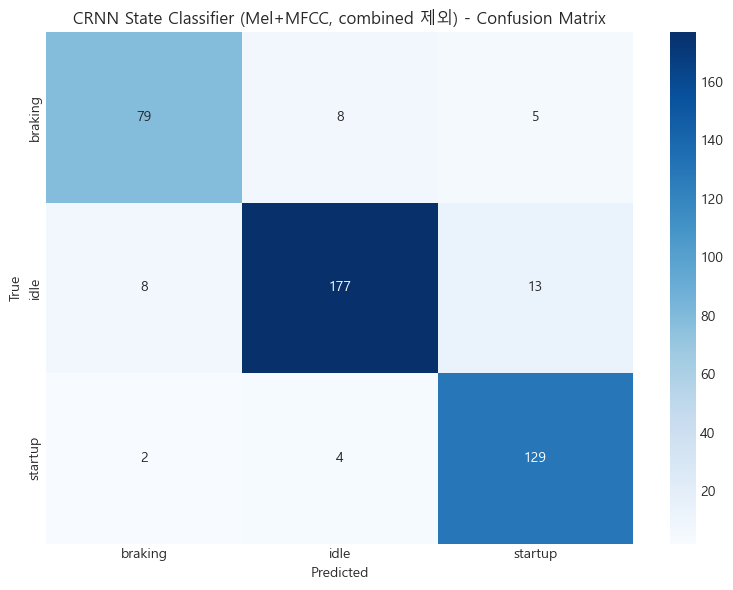

In [24]:
# ============================================================
# CRNN 모델 평가
# ============================================================

def evaluate_model(model, test_loader, device, class_names, model_name="Model"):
    """모델 평가"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_x, batch_y in tqdm(test_loader, desc=f"Evaluating {model_name}"):
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            _, preds = outputs.max(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.numpy())
    
    accuracy = 100 * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    
    print(f"\n{'='*60}")
    print(f"📊 {model_name} 테스트 결과")
    print(f"{'='*60}")
    print(f"정확도: {accuracy:.2f}%")
    
    print("\n📋 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division='warn'))
    
    # 혼동 행렬
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.tight_layout()
    plt.show()
    
    return accuracy, all_preds, all_labels

# Best 모델 로드
state_best_path = checkpoint_dir / 'state_classifier_crnn_multichannel_no_combined_best_model.pt'
if state_best_path.exists():
    checkpoint = torch.load(state_best_path, map_location=device)
    state_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Best 모델 로드 완료!")

# 평가
state_acc, state_preds, state_labels = evaluate_model(
    state_model, test_loader_s, device, state_names, "CRNN State Classifier (Mel+MFCC, combined 제외)"
)


---
## 7-2. CRNN 모델 학습 (Chroma 피처 - 최고 성능 피처)


In [ ]:
# ============================================================
# Chroma 피처용 데이터셋 클래스 정의
# ============================================================

from typing import Optional

class SoundDatasetChroma(Dataset):
    """Chroma 피처를 사용하는 차량 사운드 데이터셋"""
    
    def __init__(
        self,
        file_paths: list,
        labels: list,
        feature_extractor: AudioFeatureExtractor,
        augmentor: Optional[AudioAugmentor] = None,
        apply_spec_augment: bool = False,
        is_training: bool = True,
        target_shape: tuple = (12, 216)  # Chroma: 12개 음계
    ):
        self.file_paths = file_paths
        self.labels = labels
        self.feature_extractor = feature_extractor
        self.augmentor = augmentor
        self.apply_spec_augment = apply_spec_augment
        self.is_training = is_training
        self.target_shape = target_shape
        
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.labels[idx]
        
        # Chroma 피처 추출
        y, sr = self.feature_extractor.load_audio(str(file_path))
        chroma = self.feature_extractor.extract_chroma(y, sr)
        
        # 크기 조정
        chroma = self.feature_extractor._resize_spectrogram(chroma, self.target_shape)
        
        # 정규화
        chroma = (chroma - chroma.mean()) / (chroma.std() + 1e-8)
        
        # Chroma를 128차원으로 패딩 (CRNN 모델이 128차원을 기대)
        # 12차원을 128차원으로 확장 (반복 패딩)
        if chroma.shape[0] < 128:
            # 12차원을 반복해서 128차원으로 만들기
            repeat_factor = 128 // chroma.shape[0] + 1
            chroma_padded = np.tile(chroma, (repeat_factor, 1))[:128, :]
        else:
            chroma_padded = chroma[:128, :]
        
        # 채널 차원 추가 (1, 128, time) for CRNN
        features = chroma_padded[np.newaxis, :, :]
        
        if self.is_training and self.apply_spec_augment and self.augmentor is not None:
            features_2d = features[0]
            features_2d = self.augmentor.spec_augment(
                features_2d, num_freq_masks=2, num_time_masks=2,
                freq_mask_param=5, time_mask_param=35  # Chroma는 12차원이므로 freq_mask_param 작게
            )
            features = features_2d[np.newaxis, ...]
        
        features_tensor = torch.FloatTensor(features)
        label_tensor = torch.LongTensor([label])[0]
        
        return features_tensor, label_tensor

print("✅ SoundDatasetChroma 클래스 정의 완료!")


✅ SoundDatasetChroma 클래스 정의 완료!


In [28]:
# ============================================================
# Chroma 피처로 CRNN 모델 학습 데이터 준비
# ============================================================

# 증강기
aug_config = AugmentationConfig()
augmentor = AudioAugmentor(config=aug_config)

# 데이터셋 생성 (Chroma 피처 사용)
BATCH_SIZE = 16

train_dataset_chroma = SoundDatasetChroma(
    file_paths=X_train_s, labels=y_train_s,
    feature_extractor=feature_extractor,
    augmentor=augmentor, apply_spec_augment=True, is_training=True
)

val_dataset_chroma = SoundDatasetChroma(
    file_paths=X_val_s, labels=y_val_s,
    feature_extractor=feature_extractor,
    augmentor=None, apply_spec_augment=False, is_training=False
)

test_dataset_chroma = SoundDatasetChroma(
    file_paths=X_test_s, labels=y_test_s,
    feature_extractor=feature_extractor,
    augmentor=None, apply_spec_augment=False, is_training=False
)

train_loader_chroma = DataLoader(train_dataset_chroma, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_chroma = DataLoader(val_dataset_chroma, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_chroma = DataLoader(test_dataset_chroma, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"✅ Chroma 피처 DataLoader 생성 완료!")
print(f"   학습 배치: {len(train_loader_chroma)}, 검증 배치: {len(val_loader_chroma)}")


✅ Chroma 피처 DataLoader 생성 완료!
   학습 배치: 124, 검증 배치: 27


In [ ]:
# ============================================================
# Chroma 피처로 CRNN 모델 정의 및 학습
# ============================================================

NUM_STATES = 3  # braking, idle, startup

# 모델 생성 (Chroma: 12차원, 단일 채널)
chroma_model = SoundClassifierCRNN(
    num_classes=NUM_STATES,
    in_channels=1,  # Chroma는 단일 채널
    cnn_channels=[32, 64, 128],
    rnn_hidden_size=128,
    rnn_num_layers=2,
    dropout=0.3,
    bidirectional=True
)
chroma_model = chroma_model.to(device)

print("🏗️ CRNN 모델 (State 분류) - Chroma 피처 사용:")
print(f"   클래스: {state_names}")
print(f"   입력 피처: Chroma (12개 음계 → 128차원으로 패딩)")
print(f"   입력 형태: (1, 128, 216)")
total_params = sum(p.numel() for p in chroma_model.parameters())
print(f"   파라미터: {total_params:,}")

# 클래스 가중치
state_counts_list = [state_counts[i] for i in range(NUM_STATES)]
class_weights = 1.0 / torch.FloatTensor(state_counts_list)
class_weights = class_weights / class_weights.sum() * NUM_STATES

# 학습 설정
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = create_optimizer(chroma_model, 'adamw', lr=1e-3, weight_decay=0.01)
scheduler = create_scheduler(optimizer, 'cosine', epochs=20)

# Trainer
chroma_trainer = Trainer(
    model=chroma_model,
    train_loader=train_loader_chroma,
    val_loader=val_loader_chroma,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=str(device),
    save_dir=str(checkpoint_dir),
    experiment_name='state_classifier_crnn_chroma_no_combined',
    use_amp=(device.type == 'cuda')
)

# 학습
print("\n🚀 Chroma 피처로 CRNN 모델 학습 시작!")
print("=" * 60)

chroma_history = chroma_trainer.train(
    epochs=20,
    early_stopping_patience=7,
    save_best=True,
    verbose=True
)

print("\n✅ Chroma 피처 CRNN 모델 학습 완료!")


🏗️ CRNN 모델 (State 분류) - Chroma 피처 사용:
   클래스: ['braking', 'idle', 'startup']
   입력 피처: Chroma (12개 음계)
   입력 형태: (1, 12, 216)
   파라미터: 2,785,220

🚀 Chroma 피처로 CRNN 모델 학습 시작!

Starting training: state_classifier_crnn_chroma_no_combined
Device: cpu
Total epochs: 20



Training:   0%|          | 0/124 [00:00<?, ?it/s]


RuntimeError: input.size(-1) must be equal to input_size. Expected 2048, got 128

In [ ]:
# ============================================================
# Chroma 피처 CRNN 모델 평가
# ============================================================

# Best 모델 로드
chroma_best_path = checkpoint_dir / 'state_classifier_crnn_chroma_no_combined_best_model.pt'
if chroma_best_path.exists():
    checkpoint = torch.load(chroma_best_path, map_location=device)
    chroma_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Chroma Best 모델 로드 완료!")

# 평가
chroma_acc, chroma_preds, chroma_labels = evaluate_model(
    chroma_model, test_loader_chroma, device, state_names, "CRNN State Classifier (Chroma, combined 제외)"
)


In [ ]:
# ============================================================
# Mel+MFCC vs Chroma 성능 비교
# ============================================================

print("=" * 70)
print("📊 피처별 CRNN 모델 성능 비교")
print("=" * 70)

comparison_df = pd.DataFrame({
    '피처': ['Mel Spectrogram + MFCC', 'Chroma (최고 성능 피처)'],
    '테스트 정확도 (%)': [state_acc, chroma_acc],
    '입력 형태': ['(2, 128, 216)', '(1, 12, 216)'],
    '채널 수': [2, 1]
})

print("\n" + comparison_df.to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#4ECDC4', '#FF6B6B']
bars = ax.bar(comparison_df['피처'], comparison_df['테스트 정확도 (%)'], color=colors, alpha=0.7)

# 값 표시
for bar, acc in zip(bars, comparison_df['테스트 정확도 (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('테스트 정확도 (%)', fontsize=12)
ax.set_title('🔍 피처별 CRNN 모델 성능 비교', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(comparison_df['테스트 정확도 (%)']) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print(f"\n💡 결론:")
if chroma_acc > state_acc:
    print(f"   ✅ Chroma 피처가 {chroma_acc - state_acc:.2f}%p 더 높은 성능을 보였습니다!")
    print(f"   → 군집 분석에서 최고 성능을 보인 Chroma가 모델 학습에서도 우수한 성능을 보입니다.")
else:
    print(f"   ℹ️  Mel+MFCC가 {state_acc - chroma_acc:.2f}%p 더 높은 성능을 보였습니다.")
    print(f"   → 군집 분석 성능과 모델 학습 성능이 다를 수 있습니다.")


---
## 8. 최종 결과 요약


In [ ]:
# ============================================================
# 전체 결과 요약
# ============================================================

print("=" * 70)
print("🎉 피처 군집 분석 및 CRNN 모델 학습 완료!")
print("=" * 70)

print(f"""
📊 분석 요약:

┌─────────────────────────────────────────────────────────────────┐
│ 데이터 정보                                                      │
│   • 총 데이터: {len(all_files)}개 (combined 폴더 제외)         │
│   • 상태별 분포:                                                │
│     - braking: {state_counts[0]}개                              │
│     - idle: {state_counts[1]}개                                 │
│     - startup: {state_counts[2]}개                             │
├─────────────────────────────────────────────────────────────────┤
│ 군집 분석 결과                                                  │
│   • Silhouette Score: {silhouette:.4f}                        │
│   • Adjusted Rand Index: {ari:.4f}                            │
│   • Normalized Mutual Info: {nmi:.4f}                          │
│   • 최고 성능 피처: {best_feature}                             │
├─────────────────────────────────────────────────────────────────┤
│ CRNN 모델 성능 비교                                             │
│                                                                 │
│   [1] Mel Spectrogram + MFCC (2채널)                           │
│     • 테스트 정확도: {state_acc:.2f}%                            │
│     • 저장 경로: checkpoints/state_classifier_crnn_multichannel_no_combined_best_model.pt │
│                                                                 │
│   [2] Chroma (최고 성능 피처, 1채널)                           │
│     • 테스트 정확도: {chroma_acc:.2f}%                            │
│     • 저장 경로: checkpoints/state_classifier_crnn_chroma_no_combined_best_model.pt │
└─────────────────────────────────────────────────────────────────┘

💡 주요 특징:
  • combined 폴더 데이터 제외로 더 깔끔한 군집 분석
  • 다양한 피처 추출 방식 비교 분석 (군집 분석용)
  • 두 가지 피처로 CRNN 모델 학습 및 성능 비교
  • 군집 분석 최고 성능 피처(Chroma)와 멀티채널 피처(Mel+MFCC) 비교
""")
print("=" * 70)


🎉 피처 군집 분석 및 CRNN 모델 학습 완료!

📊 분석 요약:

┌─────────────────────────────────────────────────────────────────┐
│ 데이터 정보                                                      │
│   • 총 데이터: 2832개 (combined 폴더 제외)         │
│   • 상태별 분포:                                                │
│     - braking: 612개                              │
│     - idle: 1320개                                 │
│     - startup: 900개                             │
├─────────────────────────────────────────────────────────────────┤
│ 군집 분석 결과                                                  │
│   • Silhouette Score: 0.3826                        │
│   • Adjusted Rand Index: 0.3062                            │
│   • Normalized Mutual Info: 0.2882                          │
│   • 최고 성능 피처: chroma                             │
├─────────────────────────────────────────────────────────────────┤
│ CRNN 모델 성능                                                  │
│   • 클래스: braking, idle, startup (3개)                      │
│